## From-Scratch Implementation

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

In [10]:
class DecisionStump:
    def __init__(self):
        self.polarity = 1
        self.feature_index = None
        self.threshold = None
        self.alpha = None

    def predict(self, X):
        n_samples = X.shape[0]
        X_column = X[:, self.feature_index]
        predictions = np.ones(n_samples)

        if self.polarity == 1:
            predictions[X_column < self.threshold] = -1
        else:
            predictions[X_column > self.threshold] = -1

        return predictions


In [11]:
class AdaBoost:
    def __init__(self, n_estimators=5):
        self.n_estimators = n_estimators
        self.models = []
        self.history = []  # for visualization

    def fit(self, X, y):
        n_samples, n_features = X.shape

        # Initialize weights
        w = np.full(n_samples, (1 / n_samples))

        self.models = []
        self.history = []

        for _ in range(self.n_estimators):
            stump = DecisionStump()
            min_error = float('inf')

            # Find best stump
            for feature_i in range(n_features):
                X_column = X[:, feature_i]
                thresholds = np.unique(X_column)

                for threshold in thresholds:
                    for polarity in [1, -1]:
                        predictions = np.ones(n_samples)

                        if polarity == 1:
                            predictions[X_column < threshold] = -1
                        else:
                            predictions[X_column > threshold] = -1

                        error = np.sum(w[y != predictions])

                        if error < min_error:
                            stump.polarity = polarity
                            stump.threshold = threshold
                            stump.feature_index = feature_i
                            min_error = error

            # Avoid division by zero
            EPS = 1e-10
            stump.alpha = 0.5 * np.log((1 - min_error) / (min_error + EPS))

            # Predictions
            predictions = stump.predict(X)

            # Update weights
            w *= np.exp(-stump.alpha * y * predictions)
            w /= np.sum(w)

            # Save model and history
            self.models.append(stump)
            self.history.append((stump, w.copy()))

    def predict(self, X):
        final_predictions = np.zeros(X.shape[0])

        for stump in self.models:
            predictions = stump.predict(X)
            final_predictions += stump.alpha * predictions

        return np.sign(final_predictions)



In [13]:
def plot_decision_boundary(X, y, model, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y)
    plt.title(title)
    plt.show()

def plot_step_by_step(X, y, model):
    for i in range(1, len(model.models) + 1):
        temp_model = AdaBoost(n_estimators=i)
        temp_model.models = model.models[:i]

        plot_decision_boundary(
            X, y, temp_model,
            title=f"After {i} Weak Learners"
        )


In [14]:
X, y = make_classification(
    n_samples=100,
    n_features=2,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=42
)

In [15]:
y = np.where(y == 0, -1, 1)

In [16]:
model = AdaBoost(n_estimators=5)
model.fit(X, y)

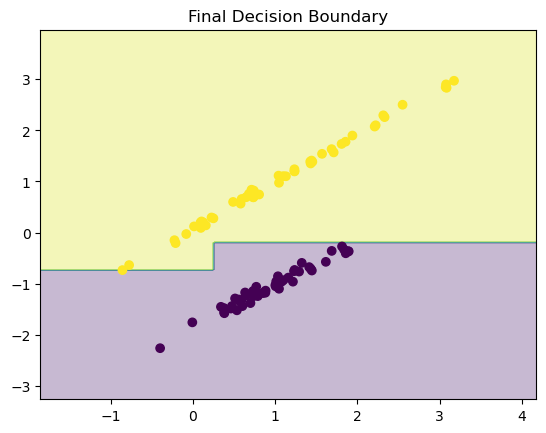

In [17]:
plot_decision_boundary(X, y, model, "Final Decision Boundary")

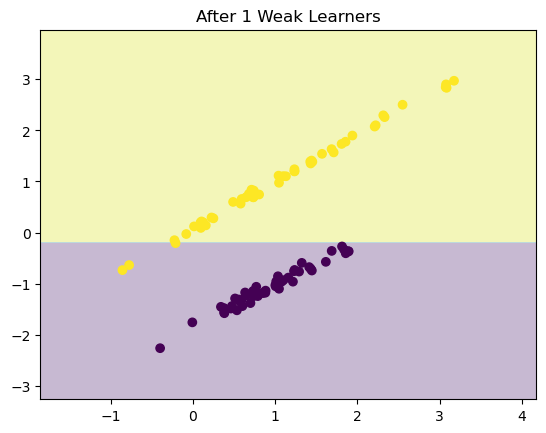

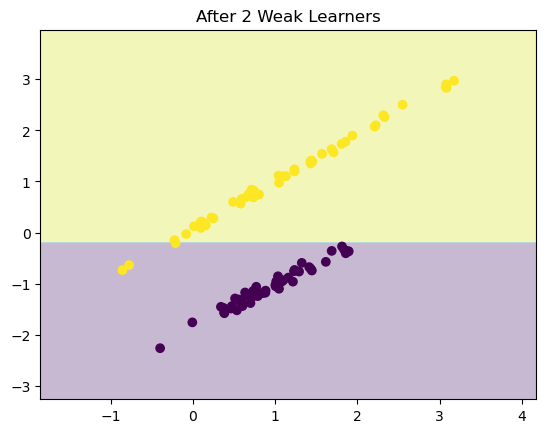

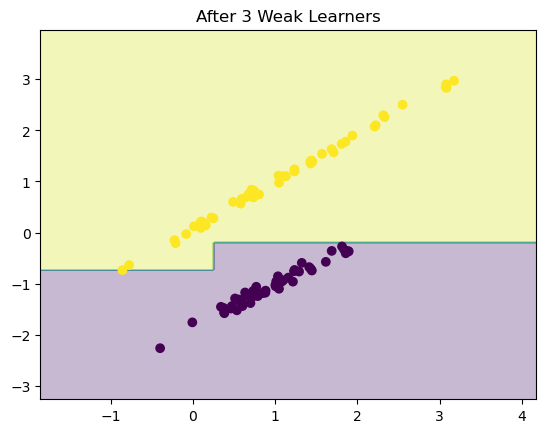

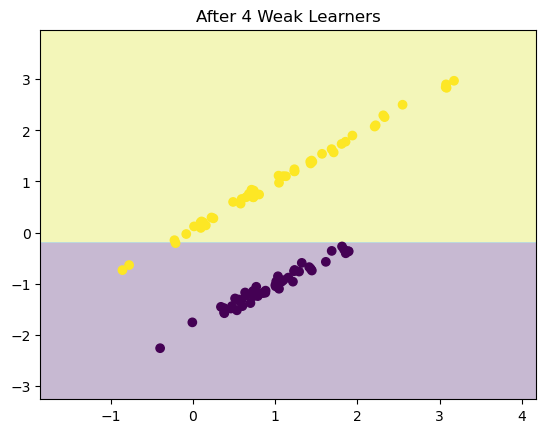

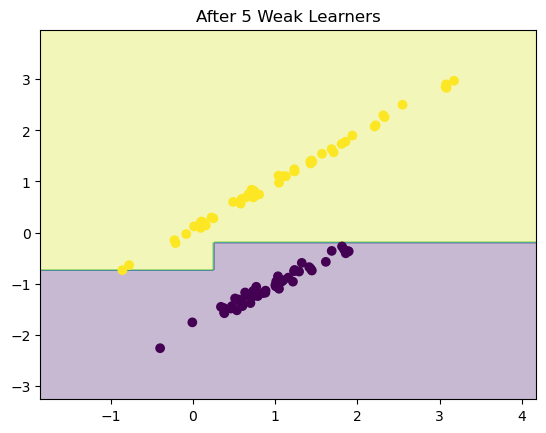

In [18]:
plot_step_by_step(X, y, model)

In [19]:
## Try to tune

In [21]:
model = AdaBoost(n_estimators=50)
model.fit(X, y)

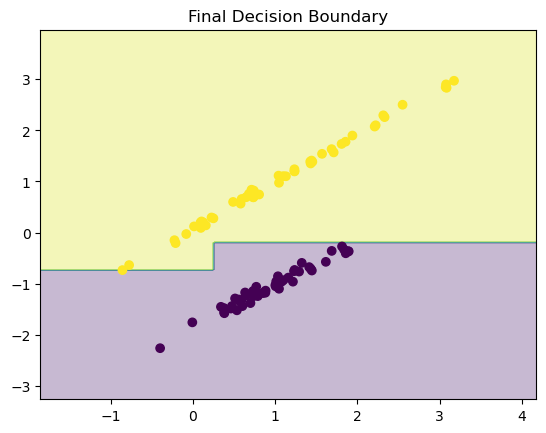

In [22]:
plot_decision_boundary(X, y, model, "Final Decision Boundary")

In [23]:
model = AdaBoost(n_estimators=1)
model.fit(X, y)

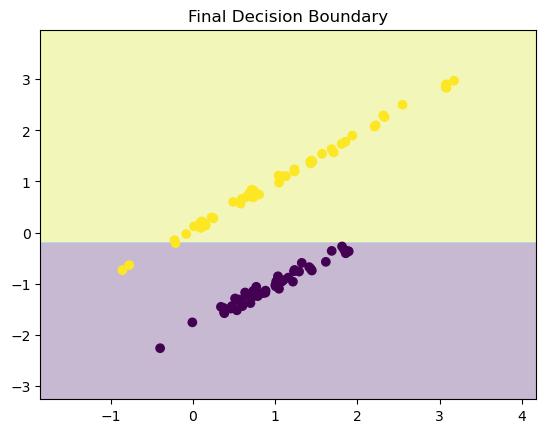

In [24]:
plot_decision_boundary(X, y, model, "Final Decision Boundary")